# Libraries

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import cv2
import torchvision.models as models
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import os
np.random.seed(42) # ensure reproducibility

# Upload Mask Images

In [52]:
def load_images_from_folder(folder_path):
    images = []
    filenames = []
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')): # objects with these extensions will be loaded
            img_path = os.path.join(folder_path, filename) # create the full path to the image file
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Or use cv2.IMREAD_COLOR for color images
            if img is not None:
                images.append(img)
                filenames.append(filename)
    return images, filenames

benign_imgs, benign_filenames = load_images_from_folder('../dataset/Benigno 437 imagenes')
malignant_imgs, malignant_filenames = load_images_from_folder('../dataset/Maligno 210 imagenes')

print(f"Benign: {len(benign_imgs)} images")
print(f"Malignant: {len(malignant_imgs)} images")

Benign: 437 images
Malignant: 210 images


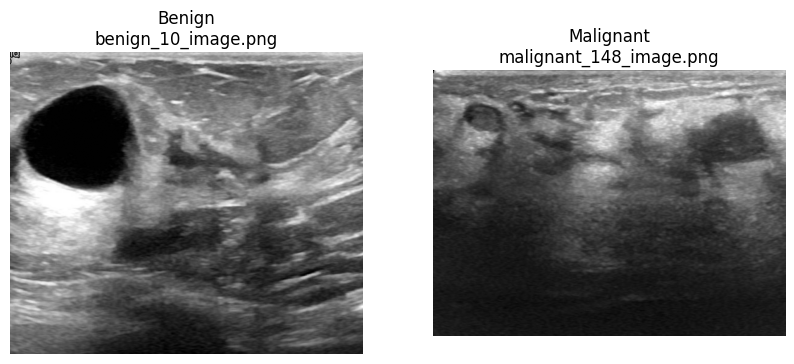

In [53]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(benign_imgs[0], cmap='gray')
plt.title(f"Benign\n{benign_filenames[0]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(malignant_imgs[1], cmap='gray')
plt.title(f"Malignant\n{malignant_filenames[0]}")
plt.axis('off')
plt.show()

# Little Preproc

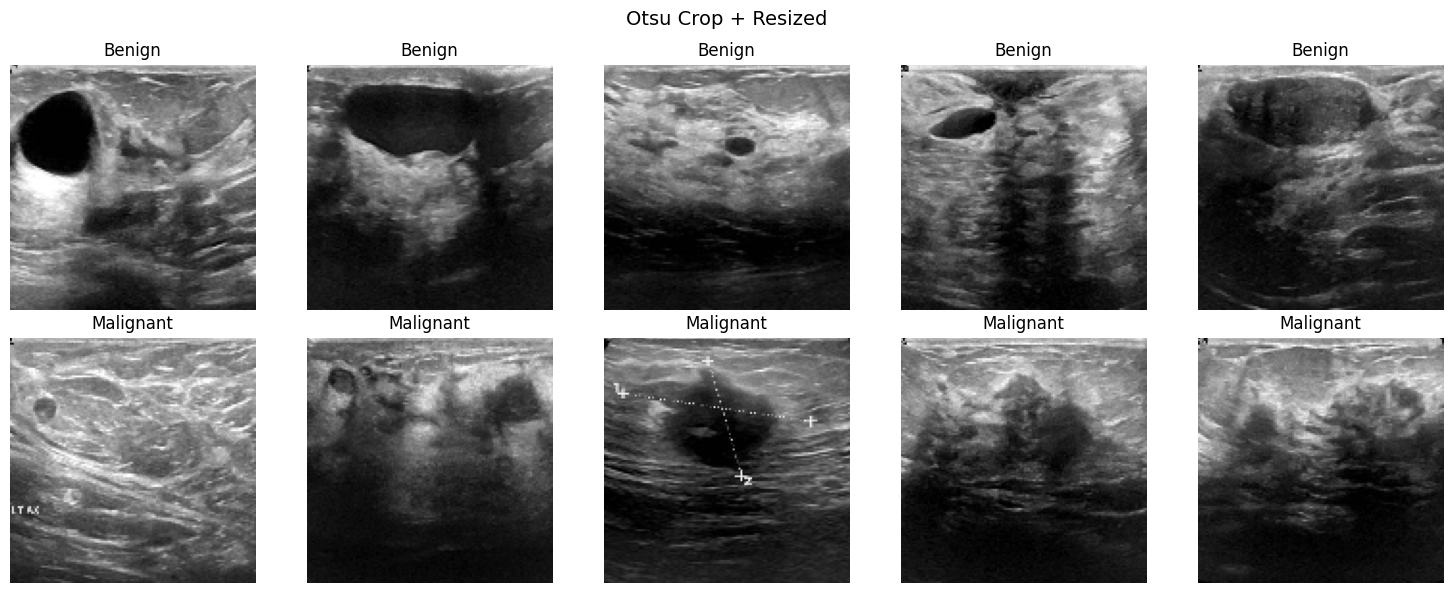

In [54]:
# resize

resize_shape = 128, 128
benign_imgs_resized    = [cv2.resize(img, resize_shape) for img in benign_imgs]
malignant_imgs_resized = [cv2.resize(img, resize_shape) for img in malignant_imgs]

# Verify visually
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(benign_imgs_resized[i], cmap='gray')
    axes[0, i].set_title('Benign')
    axes[0, i].axis('off')
    axes[1, i].imshow(malignant_imgs_resized[i], cmap='gray')
    axes[1, i].set_title('Malignant')
    axes[1, i].axis('off')
plt.suptitle('Otsu Crop + Resized', fontsize=14)
plt.tight_layout()
plt.show()

# Split data (Train, valid and test)

In [55]:
# Create image and label lists
X = benign_imgs_resized + malignant_imgs_resized
y = [0] * len(benign_imgs_resized) + [1] * len(malignant_imgs_resized)

# First split: train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Second split: validation (15%) and test (15%) from temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
# print per class

print(f"Train Benign: {y_train.count(0)} images")
print(f"Train Malignant: {y_train.count(1)} images")
print(f"Validation Benign: {y_val.count(0)} images")
print(f"Validation Malignant: {y_val.count(1)} images")
print(f"Test Benign: {y_test.count(0)} images")
print(f"Test Malignant: {y_test.count(1)} images")

Train Benign: 305 images
Train Malignant: 147 images
Validation Benign: 66 images
Validation Malignant: 31 images
Test Benign: 66 images
Test Malignant: 32 images


# Custom Dataset

In [56]:
# Augmentation only for training set
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
])

# Val and test: no augmentation, just convert to tensor
base_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

class MaskDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img   = self.images[idx].astype(np.uint8)
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img) # shape: (1, H, W)
            img = img.repeat(3, 1, 1) # shape: (3, H, W) simulate RGB
        else:
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0) / 255.0 # shape: (1, H, W), normalize to [0, 1]
            img = img.repeat(3, 1, 1) # shape: (3, H, W) simulate RGB

        return img, torch.tensor(label, dtype=torch.long)

# DataLoaders
batch_size = 32
train_dataset = MaskDataset(X_train, y_train, transform=train_transform)
val_dataset   = MaskDataset(X_val,   y_val,   transform=base_transform)
test_dataset  = MaskDataset(X_test,  y_test,  transform=base_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size)

# Simple CNN Model

In [57]:
class CNNClassifierPretrained:
    def __init__(self,
                 backbone='resnet18',
                 lr=0.001,
                 epochs=50,
                 patience=10,
                 dropout=0.5,
                 device=None):
        self.backbone = backbone
        self.lr = lr
        self.epochs = epochs
        self.patience = patience
        self.dropout = dropout
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self._build_model()

    def _build_model(self):
        if self.backbone == 'resnet18':
            model = models.resnet18(weights='IMAGENET1K_V1')
        elif self.backbone == 'resnet34':
            model = models.resnet34(weights='IMAGENET1K_V1')

        for name, param in model.named_parameters():
            if 'layer4' not in name and 'fc' not in name: # freeze layers 
                param.requires_grad = False

        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(self.dropout),
            nn.Linear(in_features, 2)
        )
        self.model = model.to(self.device)
        self.optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, self.model.parameters()), # 
            lr=self.lr
        )

    def _get_criterion(self, y_train):
        counts = np.bincount(y_train)
        weights = torch.tensor([1.0, counts[0] / counts[1]], dtype=torch.float32).to(self.device)
        return nn.CrossEntropyLoss(weight=weights)

    def fit(self, train_loader, val_loader, y_train):
        self.criterion = self._get_criterion(y_train)
        self.train_losses = []
        self.val_losses   = []
        best_val_loss     = float('inf')
        best_model_state  = None
        epochs_no_improve = 0

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            train_loss = 0
            for imgs, labels in train_loader:
                imgs, labels = imgs.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(imgs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                train_loss += loss.item() * imgs.size(0)
            train_loss /= len(train_loader.dataset)
            self.train_losses.append(train_loss)

            self.model.eval()
            val_loss = 0
            with torch.no_grad():
                for imgs, labels in val_loader:
                    imgs, labels = imgs.to(self.device), labels.to(self.device)
                    outputs = self.model(imgs)
                    loss = self.criterion(outputs, labels)
                    val_loss += loss.item() * imgs.size(0)
            val_loss /= len(val_loader.dataset)
            self.val_losses.append(val_loss)

            print(f"Epoch {epoch:3d}/{self.epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

            if val_loss < best_val_loss:
                best_val_loss    = val_loss
                best_model_state = {k: v.clone() for k, v in self.model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= self.patience:
                    print(f"\n Early stopping at epoch {epoch} ")
                    break

        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)
            print(f"\nBest model restored (val loss: {best_val_loss:.4f})")

        plt.figure(figsize=(10, 4))
        plt.plot(self.train_losses, label='Train Loss', linewidth=2)
        plt.plot(self.val_losses,   label='Val Loss',   linewidth=2, linestyle='--')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'Learning Curve - {self.backbone}')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def evaluate(self, test_loader):
        self.model.eval()
        all_preds  = []
        all_labels = []
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs = imgs.to(self.device)
                outputs = self.model(imgs)
                preds   = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        all_preds  = np.array(all_preds)
        all_labels = np.array(all_labels)

        tp = np.sum((all_labels == 1) & (all_preds == 1))
        tn = np.sum((all_labels == 0) & (all_preds == 0))
        fp = np.sum((all_labels == 0) & (all_preds == 1))
        fn = np.sum((all_labels == 1) & (all_preds == 0))
        cm = np.array([[tn, fp], [fn, tp]])

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        accuracy  = (tp + tn) / len(all_labels)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
        axes[0].set_title('Confusion Matrix - Test')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
        axes[0].set_xticklabels(['Benign', 'Malignant'])
        axes[0].set_yticklabels(['Benign', 'Malignant'])
        for i in range(2):
            for j in range(2):
                axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                             color='white' if cm[i, j] > cm.max() / 2 else 'black')
        plt.colorbar(im, ax=axes[0])

        metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
        values  = [accuracy, precision, recall, f1]
        colors  = ['steelblue', 'darkorange', 'green', 'red']
        bars    = axes[1].bar(metrics, values, color=colors)
        axes[1].set_ylim(0, 1.1)
        axes[1].set_title('Evaluation Metrics - Test')
        axes[1].set_ylabel('Value')
        for bar, val in zip(bars, values):
            axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                         f'{val:.3f}', ha='center', va='bottom', fontsize=11)
        plt.tight_layout()
        plt.show()

        print(f"\nAccuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-Score:  {f1:.4f}")

        return all_preds, all_labels

# Train Loop


Config: backbone=resnet18 | lr=0.001 | dropout=0.3
Epoch   1/50 | Train Loss: 0.8310 | Val Loss: 0.9190
Epoch   2/50 | Train Loss: 0.5156 | Val Loss: 1.1116
Epoch   3/50 | Train Loss: 0.4319 | Val Loss: 0.7857
Epoch   4/50 | Train Loss: 0.3387 | Val Loss: 0.3967
Epoch   5/50 | Train Loss: 0.3596 | Val Loss: 0.4304
Epoch   6/50 | Train Loss: 0.3060 | Val Loss: 0.3927
Epoch   7/50 | Train Loss: 0.3528 | Val Loss: 0.4508
Epoch   8/50 | Train Loss: 0.2858 | Val Loss: 0.5561
Epoch   9/50 | Train Loss: 0.2620 | Val Loss: 0.4079
Epoch  10/50 | Train Loss: 0.2543 | Val Loss: 0.3836
Epoch  11/50 | Train Loss: 0.2695 | Val Loss: 0.3706
Epoch  12/50 | Train Loss: 0.2045 | Val Loss: 0.4018
Epoch  13/50 | Train Loss: 0.2435 | Val Loss: 0.3618
Epoch  14/50 | Train Loss: 0.2470 | Val Loss: 0.4155
Epoch  15/50 | Train Loss: 0.1909 | Val Loss: 0.4212
Epoch  16/50 | Train Loss: 0.2641 | Val Loss: 0.4023
Epoch  17/50 | Train Loss: 0.2382 | Val Loss: 0.4704
Epoch  18/50 | Train Loss: 0.3061 | Val Loss: 0

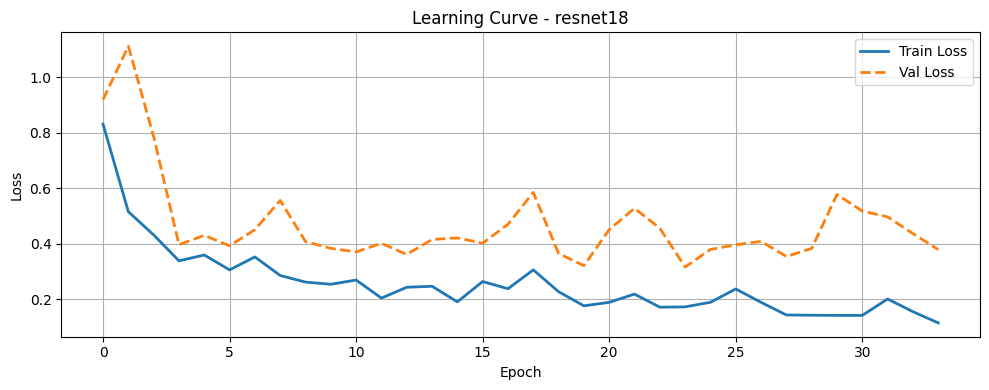

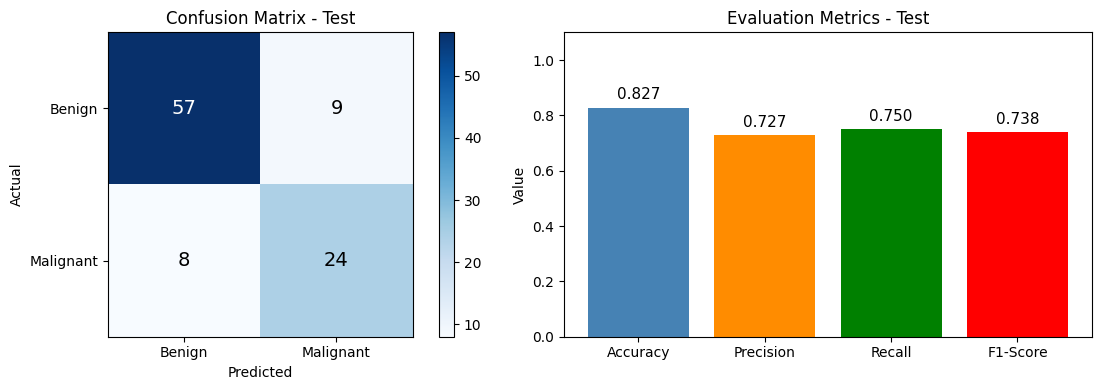


Accuracy:  0.8265
Precision: 0.7273
Recall:    0.7500
F1-Score:  0.7385

Config: backbone=resnet18 | lr=0.001 | dropout=0.5
Epoch   1/50 | Train Loss: 0.8538 | Val Loss: 3.7504
Epoch   2/50 | Train Loss: 0.6871 | Val Loss: 1.3624
Epoch   3/50 | Train Loss: 0.4220 | Val Loss: 0.8618
Epoch   4/50 | Train Loss: 0.3430 | Val Loss: 0.6068
Epoch   5/50 | Train Loss: 0.3958 | Val Loss: 0.5463
Epoch   6/50 | Train Loss: 0.3315 | Val Loss: 0.7808
Epoch   7/50 | Train Loss: 0.3680 | Val Loss: 0.4210
Epoch   8/50 | Train Loss: 0.3236 | Val Loss: 0.4465
Epoch   9/50 | Train Loss: 0.2722 | Val Loss: 0.4545
Epoch  10/50 | Train Loss: 0.2599 | Val Loss: 0.4097
Epoch  11/50 | Train Loss: 0.2471 | Val Loss: 0.4308
Epoch  12/50 | Train Loss: 0.2736 | Val Loss: 0.5215
Epoch  13/50 | Train Loss: 0.2502 | Val Loss: 0.4303
Epoch  14/50 | Train Loss: 0.2807 | Val Loss: 0.5055
Epoch  15/50 | Train Loss: 0.2896 | Val Loss: 0.4753
Epoch  16/50 | Train Loss: 0.2171 | Val Loss: 0.3897
Epoch  17/50 | Train Loss: 

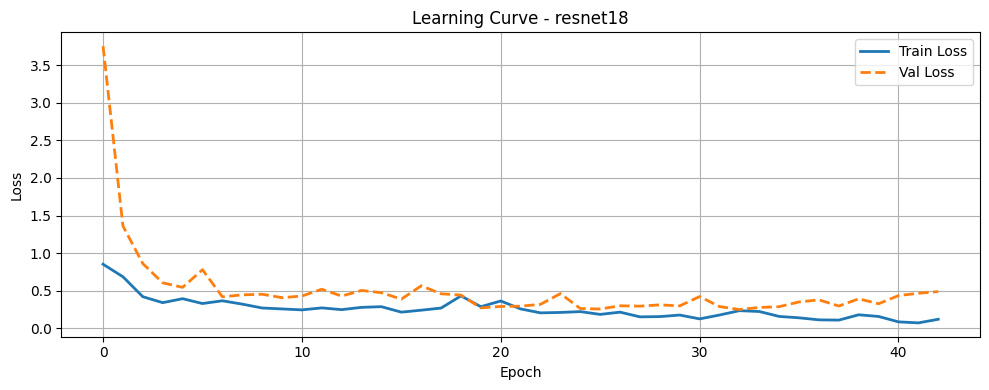

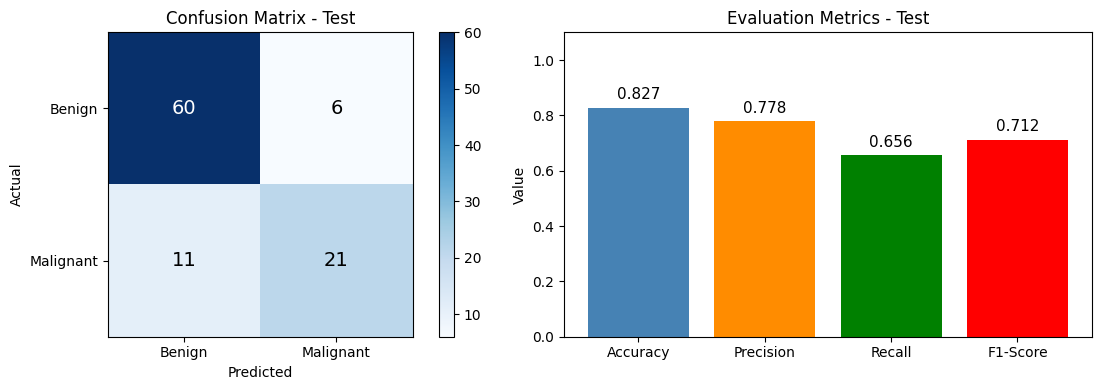


Accuracy:  0.8265
Precision: 0.7778
Recall:    0.6562
F1-Score:  0.7119

Config: backbone=resnet18 | lr=0.0005 | dropout=0.3
Epoch   1/50 | Train Loss: 0.6730 | Val Loss: 0.6496
Epoch   2/50 | Train Loss: 0.5975 | Val Loss: 0.5790
Epoch   3/50 | Train Loss: 0.3998 | Val Loss: 0.6974
Epoch   4/50 | Train Loss: 0.3708 | Val Loss: 0.5071
Epoch   5/50 | Train Loss: 0.3273 | Val Loss: 0.4578
Epoch   6/50 | Train Loss: 0.2860 | Val Loss: 0.4253
Epoch   7/50 | Train Loss: 0.2458 | Val Loss: 0.3985
Epoch   8/50 | Train Loss: 0.2735 | Val Loss: 0.4721
Epoch   9/50 | Train Loss: 0.2627 | Val Loss: 0.5068
Epoch  10/50 | Train Loss: 0.2176 | Val Loss: 0.3923
Epoch  11/50 | Train Loss: 0.2208 | Val Loss: 0.4468
Epoch  12/50 | Train Loss: 0.2721 | Val Loss: 0.4785
Epoch  13/50 | Train Loss: 0.1933 | Val Loss: 0.4821
Epoch  14/50 | Train Loss: 0.2136 | Val Loss: 0.8715
Epoch  15/50 | Train Loss: 0.2989 | Val Loss: 0.4943
Epoch  16/50 | Train Loss: 0.1978 | Val Loss: 0.4876
Epoch  17/50 | Train Loss:

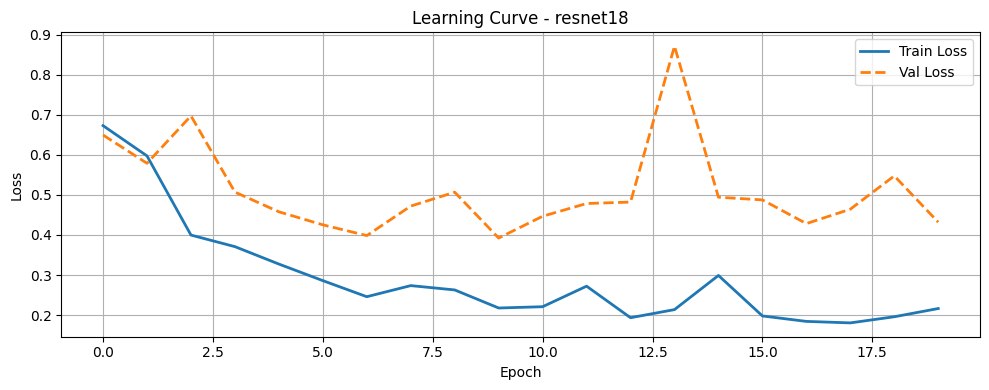

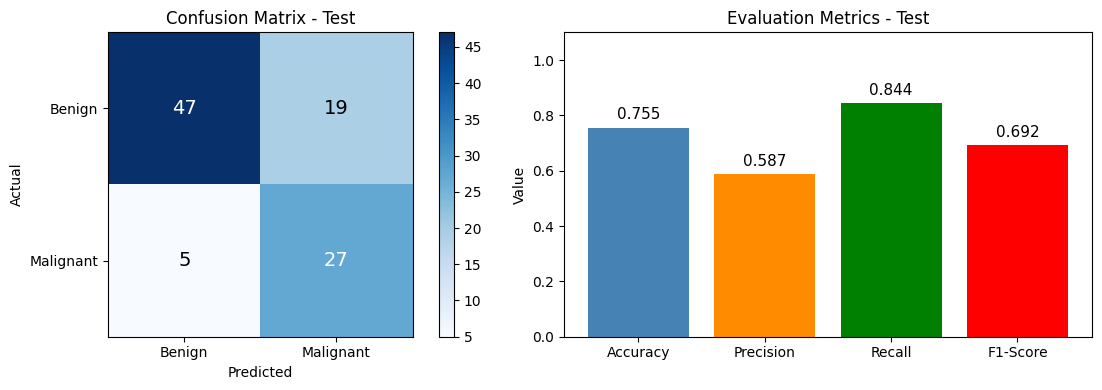


Accuracy:  0.7551
Precision: 0.5870
Recall:    0.8438
F1-Score:  0.6923

Config: backbone=resnet18 | lr=0.0005 | dropout=0.5
Epoch   1/50 | Train Loss: 0.7100 | Val Loss: 0.7681
Epoch   2/50 | Train Loss: 0.6036 | Val Loss: 1.3279
Epoch   3/50 | Train Loss: 0.4792 | Val Loss: 0.6636
Epoch   4/50 | Train Loss: 0.4314 | Val Loss: 0.9066
Epoch   5/50 | Train Loss: 0.4504 | Val Loss: 0.4099
Epoch   6/50 | Train Loss: 0.3333 | Val Loss: 0.4465
Epoch   7/50 | Train Loss: 0.4132 | Val Loss: 0.4256
Epoch   8/50 | Train Loss: 0.3174 | Val Loss: 0.3998
Epoch   9/50 | Train Loss: 0.2395 | Val Loss: 0.4004
Epoch  10/50 | Train Loss: 0.2177 | Val Loss: 0.4013
Epoch  11/50 | Train Loss: 0.2112 | Val Loss: 0.4162
Epoch  12/50 | Train Loss: 0.2443 | Val Loss: 0.6459
Epoch  13/50 | Train Loss: 0.2654 | Val Loss: 0.9719
Epoch  14/50 | Train Loss: 0.3191 | Val Loss: 0.4545
Epoch  15/50 | Train Loss: 0.2686 | Val Loss: 0.3583
Epoch  16/50 | Train Loss: 0.2273 | Val Loss: 0.4461
Epoch  17/50 | Train Loss:

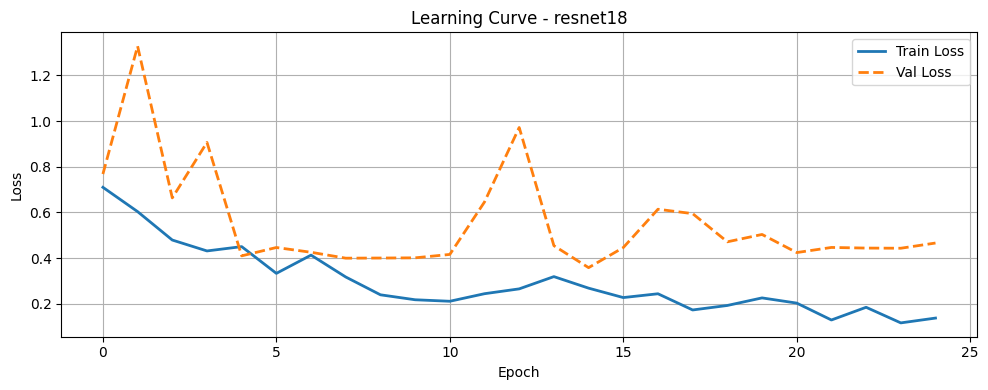

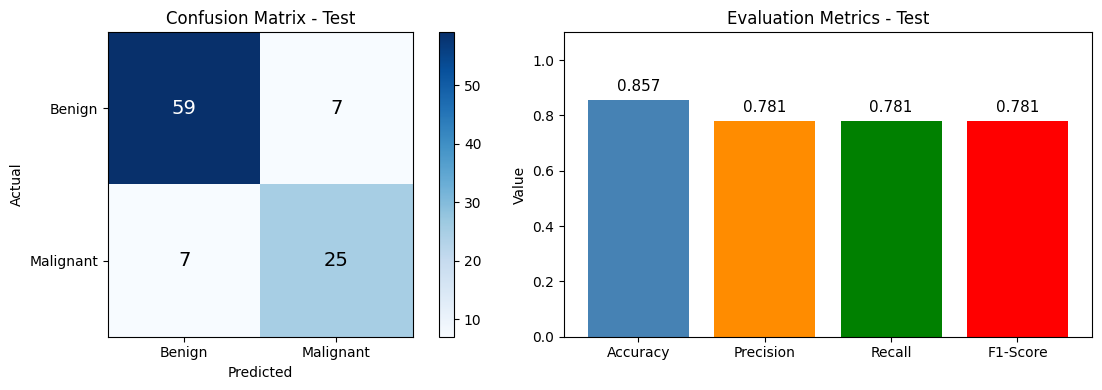


Accuracy:  0.8571
Precision: 0.7812
Recall:    0.7812
F1-Score:  0.7812

Config: backbone=resnet34 | lr=0.001 | dropout=0.3
Epoch   1/50 | Train Loss: 0.8019 | Val Loss: 5.4086
Epoch   2/50 | Train Loss: 0.6367 | Val Loss: 1.0686
Epoch   3/50 | Train Loss: 0.4705 | Val Loss: 0.8225
Epoch   4/50 | Train Loss: 0.4087 | Val Loss: 0.5319
Epoch   5/50 | Train Loss: 0.3922 | Val Loss: 0.4849
Epoch   6/50 | Train Loss: 0.3186 | Val Loss: 0.4669
Epoch   7/50 | Train Loss: 0.3184 | Val Loss: 0.4940
Epoch   8/50 | Train Loss: 0.2635 | Val Loss: 0.5719
Epoch   9/50 | Train Loss: 0.3042 | Val Loss: 0.4784
Epoch  10/50 | Train Loss: 0.3262 | Val Loss: 0.4430
Epoch  11/50 | Train Loss: 0.2120 | Val Loss: 0.4757
Epoch  12/50 | Train Loss: 0.2639 | Val Loss: 0.6927
Epoch  13/50 | Train Loss: 0.2323 | Val Loss: 0.5408
Epoch  14/50 | Train Loss: 0.2303 | Val Loss: 0.5672
Epoch  15/50 | Train Loss: 0.2216 | Val Loss: 0.5201
Epoch  16/50 | Train Loss: 0.1815 | Val Loss: 0.3975
Epoch  17/50 | Train Loss: 

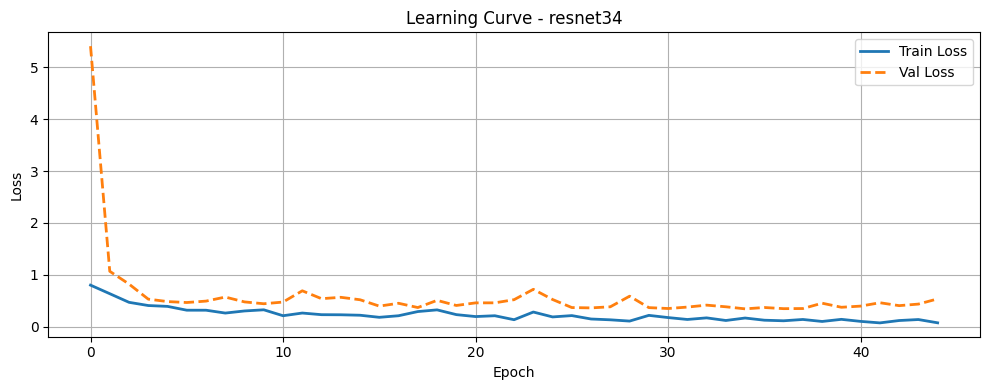

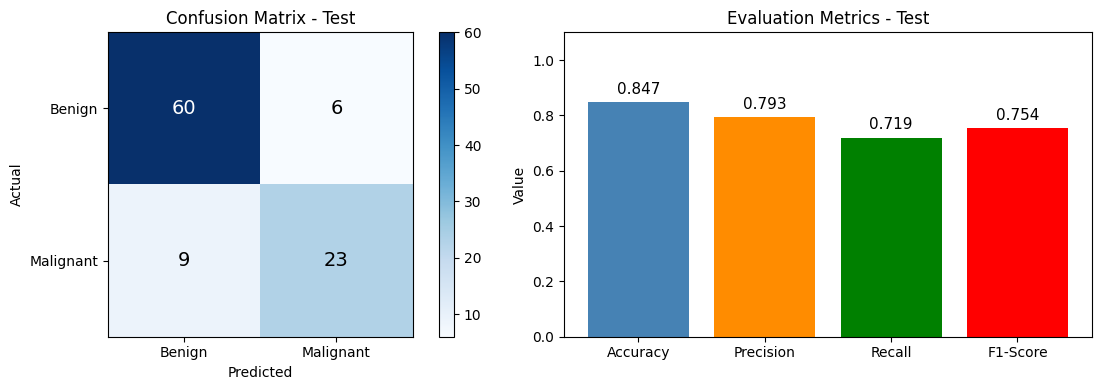


Accuracy:  0.8469
Precision: 0.7931
Recall:    0.7188
F1-Score:  0.7541

Config: backbone=resnet34 | lr=0.0005 | dropout=0.5
Epoch   1/50 | Train Loss: 0.8109 | Val Loss: 1.5397
Epoch   2/50 | Train Loss: 0.6399 | Val Loss: 0.7863
Epoch   3/50 | Train Loss: 0.5004 | Val Loss: 0.9030
Epoch   4/50 | Train Loss: 0.4529 | Val Loss: 0.6785
Epoch   5/50 | Train Loss: 0.3589 | Val Loss: 0.6512
Epoch   6/50 | Train Loss: 0.2968 | Val Loss: 0.6619
Epoch   7/50 | Train Loss: 0.3474 | Val Loss: 0.5189
Epoch   8/50 | Train Loss: 0.2819 | Val Loss: 0.6397
Epoch   9/50 | Train Loss: 0.2134 | Val Loss: 0.4707
Epoch  10/50 | Train Loss: 0.2068 | Val Loss: 0.5521
Epoch  11/50 | Train Loss: 0.3239 | Val Loss: 0.4769
Epoch  12/50 | Train Loss: 0.2164 | Val Loss: 0.4676
Epoch  13/50 | Train Loss: 0.1937 | Val Loss: 0.7513
Epoch  14/50 | Train Loss: 0.2255 | Val Loss: 0.6837
Epoch  15/50 | Train Loss: 0.2802 | Val Loss: 0.4469
Epoch  16/50 | Train Loss: 0.2436 | Val Loss: 0.5133
Epoch  17/50 | Train Loss:

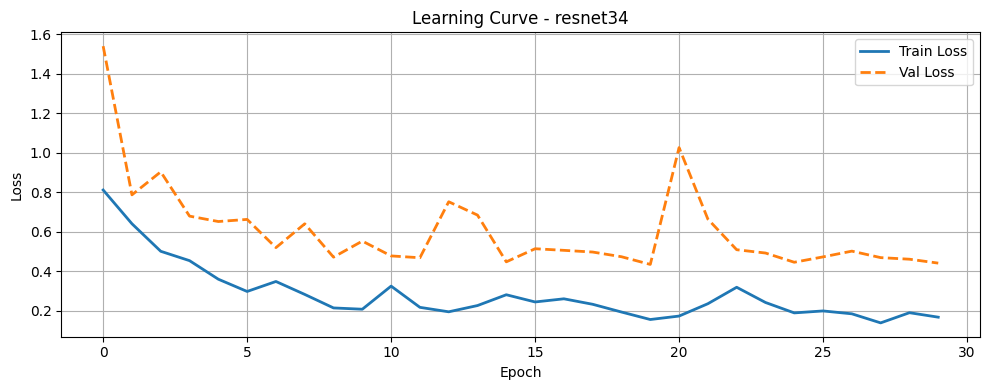

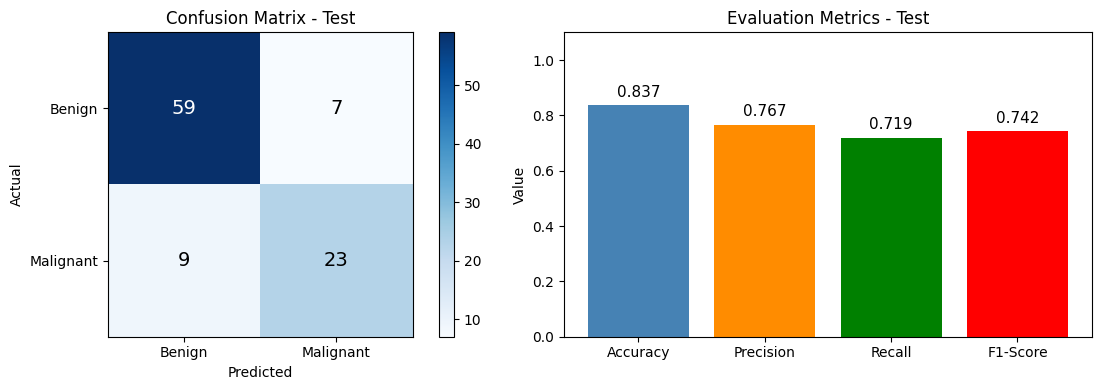


Accuracy:  0.8367
Precision: 0.7667
Recall:    0.7188
F1-Score:  0.7419

                      RESULTS SUMMARY                       
Backbone          LR  Dropout     Acc      F1
------------------------------------------------------------
resnet18       0.001      0.3  0.8265  0.7385
resnet18       0.001      0.5  0.8265  0.7119
resnet18      0.0005      0.3  0.7551  0.6923
resnet18      0.0005      0.5  0.8571  0.7812
resnet34       0.001      0.3  0.8469  0.7541
resnet34      0.0005      0.5  0.8367  0.7419

→ Best: backbone=resnet18 | lr=0.0005 | dropout=0.5 | F1=0.7812


In [60]:
configs = [
    {'backbone': 'resnet18', 'lr': 0.001,  'dropout': 0.3},
    {'backbone': 'resnet18', 'lr': 0.001,  'dropout': 0.5},
    {'backbone': 'resnet18', 'lr': 0.0005, 'dropout': 0.3},
    {'backbone': 'resnet18', 'lr': 0.0005, 'dropout': 0.5},
    {'backbone': 'resnet34', 'lr': 0.001,  'dropout': 0.3},
    {'backbone': 'resnet34', 'lr': 0.0005, 'dropout': 0.5},
]

results = []
for cfg in configs:
    print(f"\n{'='*60}")
    print(f"Config: backbone={cfg['backbone']} | lr={cfg['lr']} | dropout={cfg['dropout']}")
    print('='*60)

    cnn = CNNClassifierPretrained(
        backbone=cfg['backbone'],
        lr=cfg['lr'],
        dropout=cfg['dropout'],
        epochs=50,
        patience=10
    )
    cnn.fit(train_loader, val_loader, y_train)
    preds, labels = cnn.evaluate(test_loader)

    tp = np.sum((np.array(labels) == 1) & (np.array(preds) == 1))
    fp = np.sum((np.array(labels) == 0) & (np.array(preds) == 1))
    fn = np.sum((np.array(labels) == 1) & (np.array(preds) == 0))
    tn = np.sum((np.array(labels) == 0) & (np.array(preds) == 0))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy  = (tp + tn) / len(labels)

    results.append({**cfg, 'f1': f1, 'accuracy': accuracy})

# Summary
print(f"\n{'='*60}")
print(f"{'RESULTS SUMMARY':^60}")
print(f"{'='*60}")
print(f"{'Backbone':<12} {'LR':>7} {'Dropout':>8} {'Acc':>7} {'F1':>7}")
print(f"{'-'*60}")
for r in results:
    print(f"{r['backbone']:<12} {r['lr']:>7} {r['dropout']:>8} {r['accuracy']:>7.4f} {r['f1']:>7.4f}")

best = max(results, key=lambda x: x['f1'])
print(f"\n→ Best: backbone={best['backbone']} | lr={best['lr']} | dropout={best['dropout']} | F1={best['f1']:.4f}")

# Grad-CAM to WarmMap

Epoch   1/50 | Train Loss: 0.7214 | Val Loss: 0.5520
Epoch   2/50 | Train Loss: 0.5083 | Val Loss: 0.6127
Epoch   3/50 | Train Loss: 0.3883 | Val Loss: 0.5504
Epoch   4/50 | Train Loss: 0.3585 | Val Loss: 0.6969
Epoch   5/50 | Train Loss: 0.3574 | Val Loss: 0.3951
Epoch   6/50 | Train Loss: 0.4285 | Val Loss: 0.3840
Epoch   7/50 | Train Loss: 0.3004 | Val Loss: 0.3743
Epoch   8/50 | Train Loss: 0.3360 | Val Loss: 0.4104
Epoch   9/50 | Train Loss: 0.2963 | Val Loss: 0.4768
Epoch  10/50 | Train Loss: 0.3249 | Val Loss: 0.3584
Epoch  11/50 | Train Loss: 0.2332 | Val Loss: 0.3875
Epoch  12/50 | Train Loss: 0.2063 | Val Loss: 0.4220
Epoch  13/50 | Train Loss: 0.2311 | Val Loss: 0.4403
Epoch  14/50 | Train Loss: 0.2476 | Val Loss: 0.3638
Epoch  15/50 | Train Loss: 0.1878 | Val Loss: 0.3563
Epoch  16/50 | Train Loss: 0.2223 | Val Loss: 0.3076
Epoch  17/50 | Train Loss: 0.1775 | Val Loss: 0.4382
Epoch  18/50 | Train Loss: 0.1846 | Val Loss: 0.3647
Epoch  19/50 | Train Loss: 0.2295 | Val Loss: 

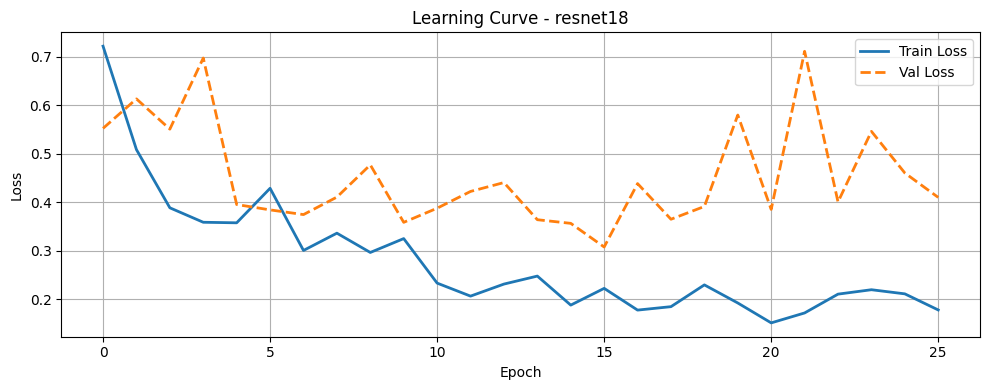

/home/doncho/Projects/Computational_Inteligence_Fundaments/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


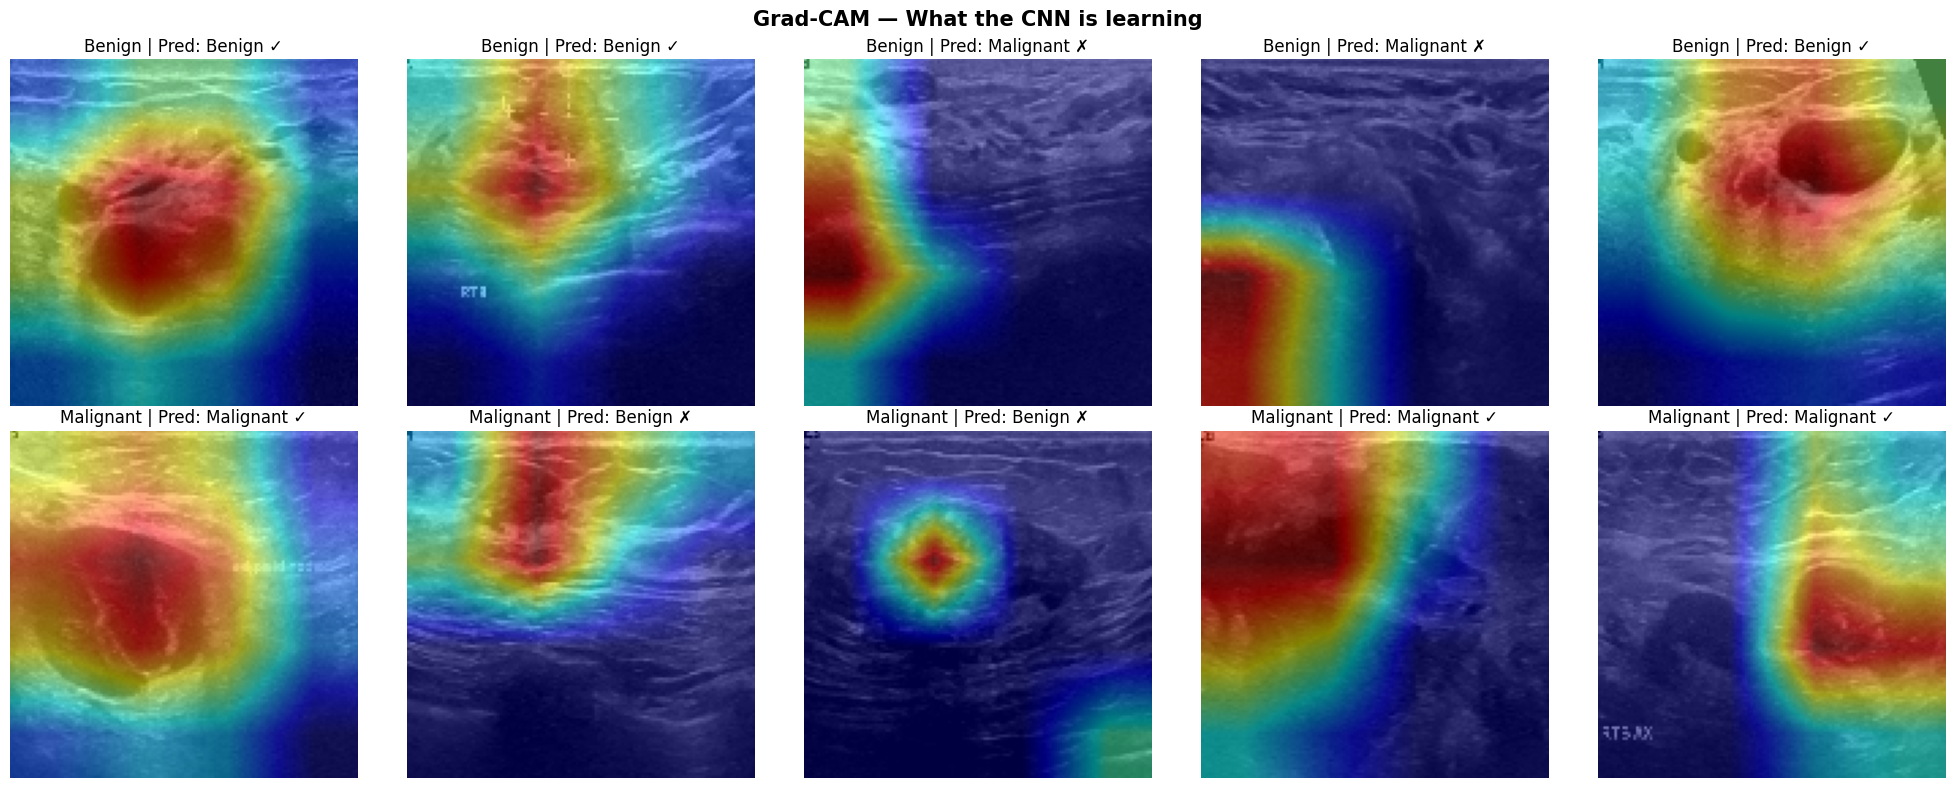

In [61]:
def grad_cam(model, image_tensor, target_layer, device):
    model.eval()
    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    fwd_handle = target_layer.register_forward_hook(forward_hook)
    bwd_handle = target_layer.register_backward_hook(backward_hook)

    image_tensor = image_tensor.unsqueeze(0).to(device)
    output = model(image_tensor)
    pred_class = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, pred_class].backward()

    fwd_handle.remove()
    bwd_handle.remove()

    grads = gradients[0].squeeze() # (C, H, W)
    acts  = activations[0].squeeze() # (C, H, W)
    weights = grads.mean(dim=(1, 2)) # (C,)
    cam = (weights[:, None, None] * acts).sum(dim=0)
    cam = torch.relu(cam).cpu().detach().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, pred_class

def show_grad_cam(model, images, labels, class_names, device, n=5):
    # Target last conv layer of ResNet
    target_layer = model.layer4[-1].conv2
    
    fig, axes = plt.subplots(2, n, figsize=(n * 4, 8))
    
    shown = {0: 0, 1: 0}
    samples = {0: [], 1: []}
    
    # Collect n samples per class
    for img, label in zip(images, labels):
        if shown[label] < n:
            samples[label].append((img, label))
            shown[label] += 1
        if shown[0] == n and shown[1] == n:
            break

    for col in range(n):
        for row, cls in enumerate([0, 1]):
            img_np, label = samples[cls][col]
            img_uint8 = img_np.astype(np.uint8)
            
            # Prepare tensor
            img_tensor = base_transform(img_uint8).repeat(3, 1, 1)
            
            cam, pred = grad_cam(model, img_tensor, target_layer, device)
            cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
            
            # Overlay heatmap on original image
            img_color = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)
            heatmap   = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
            overlay   = cv2.addWeighted(img_color, 0.5, heatmap, 0.5, 0)
            overlay   = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
            
            correct = '✓' if pred == label else '✗'
            axes[row, col].imshow(overlay)
            axes[row, col].set_title(f'{class_names[label]} | Pred: {class_names[pred]} {correct}')
            axes[row, col].axis('off')

    axes[0, 0].set_ylabel('Benign', fontsize=13, fontweight='bold')
    axes[1, 0].set_ylabel('Malignant', fontsize=13, fontweight='bold')
    plt.suptitle('Grad-CAM — What the CNN is learning', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run on best model
best_cnn = CNNClassifierPretrained(backbone='resnet18', lr=0.0005, dropout=0.5, epochs=50, patience=10)
best_cnn.fit(train_loader, val_loader, y_train)

show_grad_cam(
    model       = best_cnn.model,
    images      = X_test,
    labels      = y_test,
    class_names = ['Benign', 'Malignant'],
    device      = best_cnn.device,
    n           = 5
)

# Conclusions

- Transfer Learning Challenges
Replicating the grayscale channel to fit ResNet's RGB input preserved ImageNet weights but did not compensate for the lack of explicit tumor localization.

- Feature Misalignment and Noise
Grad-CAM visualizations confirmed the network often focused on background speckle noise and peripheral tissue textures rather than clinically relevant malignant features.

- Impact of ROI Absence
The absence of aligned Region of Interest (ROI) annotations forced the CNN to learn global image patterns, resulting in a significant performance drop compared to mask-based models.

- Dataset and Structural Limitations
The 1:N image-to-mask ratio prevented automated cropping, while the small dataset size proved insufficient for the model to learn autonomous tumor localization.

- Model Performance Ceiling
An F1-score of 0.7812 represents the limit for this architecture without expert-guided segmentation, highlighting the necessity of a two-stage detection-classification pipeline.